# Notebook 84 — raw TimTrack alpha production-chain audit

This notebook targets the raw TimTrack alpha path itself: image/mask inputs, candidate generation, and pre-persistence angle/peak aggregation.

In [1]:
from pathlib import Path
import subprocess
import sys
from IPython.display import Markdown, Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent
SCRIPT = ROOT / 'scripts' / 'evaluate_raw_timtrack_alpha_chain.py'
OUT = ROOT / 'results' / 'notebook84_raw_timtrack_alpha_chain'
print(f'Project root: {ROOT}')
print(f'Script: {SCRIPT}')
print(f'Output directory: {OUT}')

Project root: /Users/grosbedou/PycharmProjects/NDORMS
Script: /Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_raw_timtrack_alpha_chain.py
Output directory: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook84_raw_timtrack_alpha_chain


In [2]:
completed = subprocess.run([sys.executable, str(SCRIPT)], check=True)
completed

# Notebook 84 — raw TimTrack alpha production-chain audit

Audited 48 representative aligned frames: 30 worst raw-alpha mismatch frames plus 18 control frames.

This notebook targets the raw TimTrack alpha production chain before persistence. It recomputes per-frame TimTrack geofeatures directly from the video under several mask-input variants, then separates candidate-generation failure from pre-persistence peak aggregation failure.

## Key findings

- On the baseline image path (`matlab_literal` subtraction + saved/`parms` Emask reuse), recomputed raw alpha matches the saved Python raw alpha closely on the sample (RMSE 0.0000 deg). So the notebook is auditing the same raw chain the strict run used, not a different one.
- The baseline raw-alpha RMSE on the sampled frames is 10.0315 deg.
- The baseline nearest-candidate error is much smaller, RMSE 1.4825 deg, with a MATLAB-like candidate within 1° on 75.0% of sampled frames and within 2° on 87.5% of sampled frames.
- But even when such

CompletedProcess(args=['/Users/grosbedou/PycharmProjects/NDORMS/.venv/bin/python', '/Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_raw_timtrack_alpha_chain.py'], returncode=0)

In [3]:
display(Markdown((OUT / 'notebook84_summary.md').read_text()))

# Notebook 84 — raw TimTrack alpha production-chain audit

Audited 48 representative aligned frames: 30 worst raw-alpha mismatch frames plus 18 control frames.

This notebook targets the raw TimTrack alpha production chain before persistence. It recomputes per-frame TimTrack geofeatures directly from the video under several mask-input variants, then separates candidate-generation failure from pre-persistence peak aggregation failure.

## Key findings

- On the baseline image path (`matlab_literal` subtraction + saved/`parms` Emask reuse), recomputed raw alpha matches the saved Python raw alpha closely on the sample (RMSE 0.0000 deg). So the notebook is auditing the same raw chain the strict run used, not a different one.
- The baseline raw-alpha RMSE on the sampled frames is 10.0315 deg.
- The baseline nearest-candidate error is much smaller, RMSE 1.4825 deg, with a MATLAB-like candidate within 1° on 75.0% of sampled frames and within 2° on 87.5% of sampled frames.
- But even when such a close candidate is present, the weighted-median alpha still lands >5° away from MATLAB on 37.5% of sampled frames. That means a substantial part of the raw-alpha gap is already a pre-persistence peak-aggregation/selection problem, not only a missing candidate problem.
- Image/mask inputs still matter. Across the tested variants, the best raw-alpha RMSE is 6.6057 deg for `line_mask__dynamic`, versus 10.0315 deg at baseline. The same variant also changes candidate-hit behavior and masked-pixel density, so mask construction is not neutral.
- Angle/sign convention does not look like the main issue. On the baseline sample, the best simple transform is `identity_alpha` with RMSE 10.0315 deg, and the identity convention is already the best or tied-best among the tested simple alternatives.

## Interpretation

- The raw TimTrack gap is not mainly caused by the later persistence layer.
- It is also not well explained by a simple sign/complement convention error.
- The problem splits into two upstream pieces:

  1. mask/input sensitivity changes which candidate peaks are produced;
  2. even when a good candidate exists, the current peak aggregation can still choose the wrong raw alpha.

- That makes the next safest code-facing target narrower: notebook-only experiments around raw Hough peak aggregation and mask construction, before any production patch.

- Variant summary CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook84_raw_timtrack_alpha_chain/raw_timtrack_chain_variant_summary.csv`
- Per-frame detail CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook84_raw_timtrack_alpha_chain/raw_timtrack_chain_frame_details.csv`
- Angle convention CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook84_raw_timtrack_alpha_chain/angle_convention_transforms.csv`
- Worst-frame CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook84_raw_timtrack_alpha_chain/sampled_worst_frames.csv`
- Summary plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook84_raw_timtrack_alpha_chain/raw_timtrack_chain_summary.png`
- Convention plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook84_raw_timtrack_alpha_chain/angle_convention_check.png`
- Exemplar overlays: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook84_raw_timtrack_alpha_chain/raw_timtrack_exemplar_overlays.png`


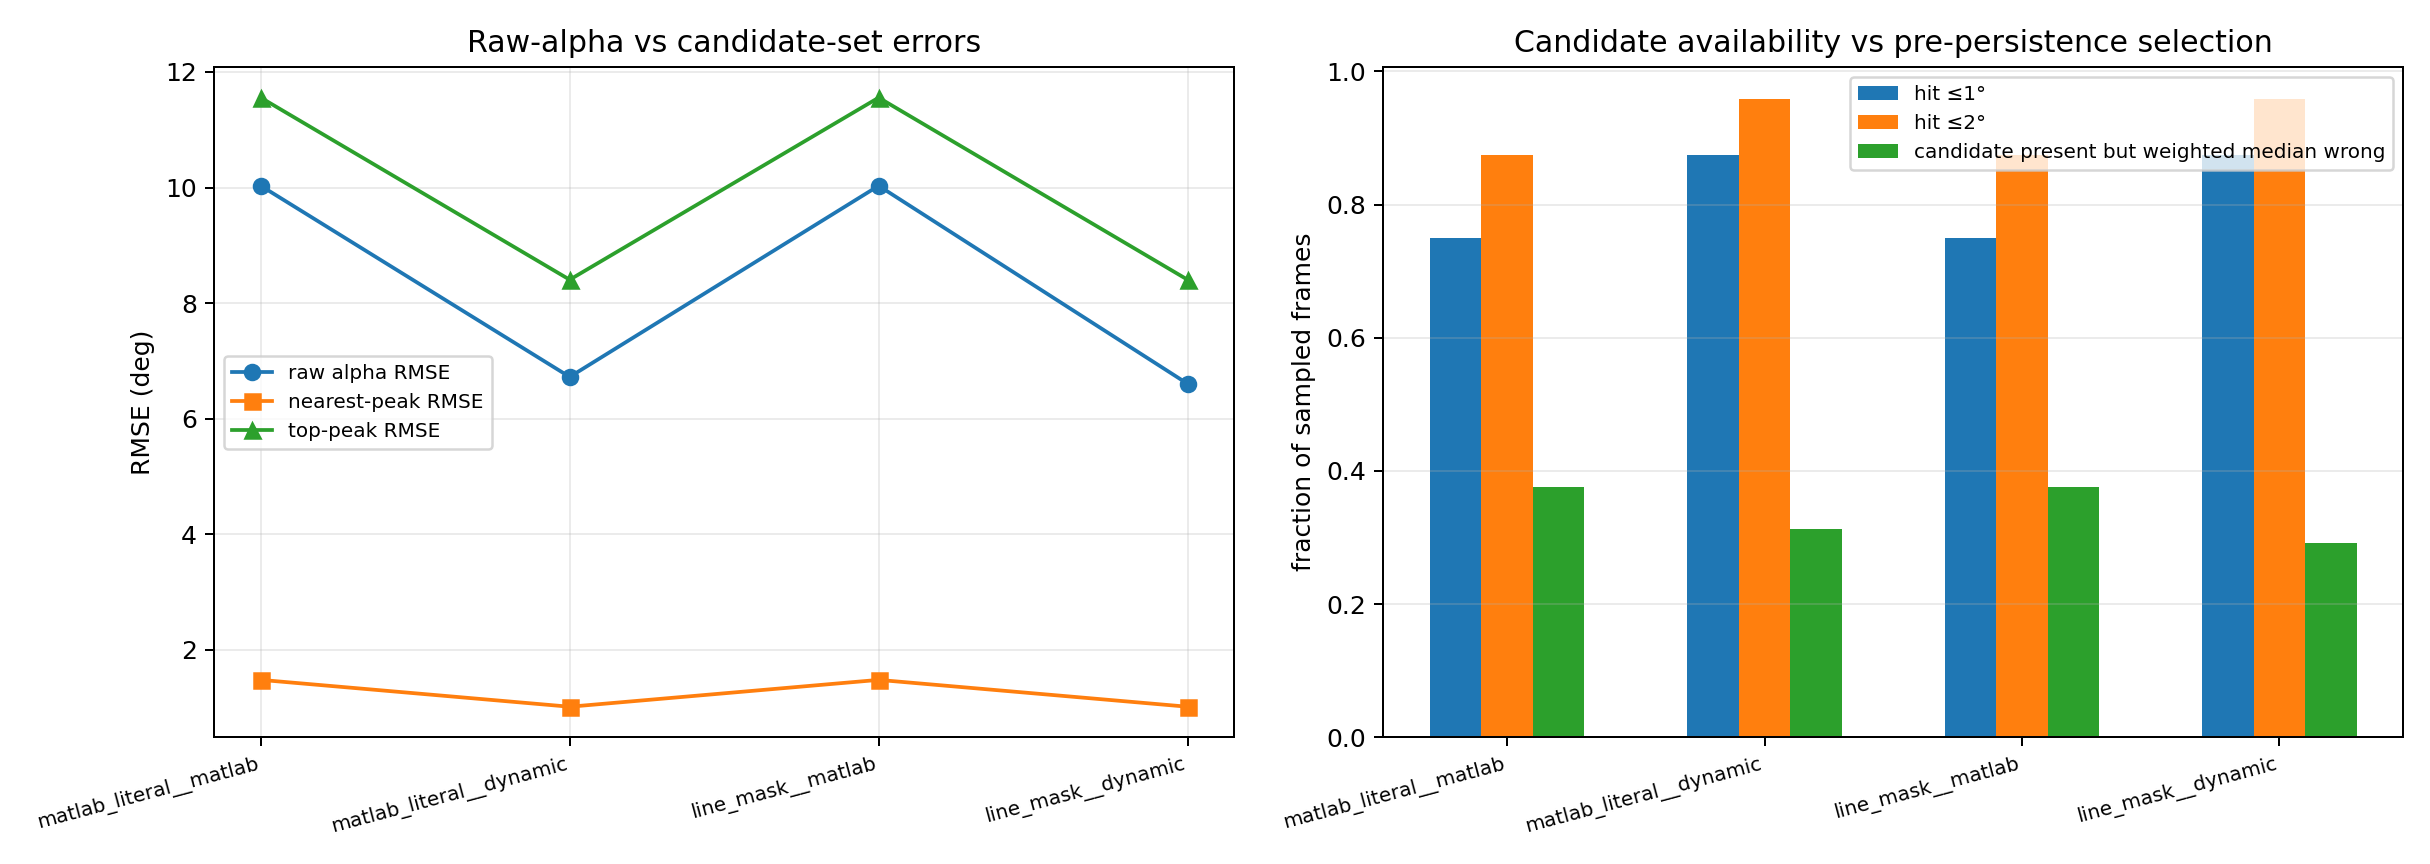

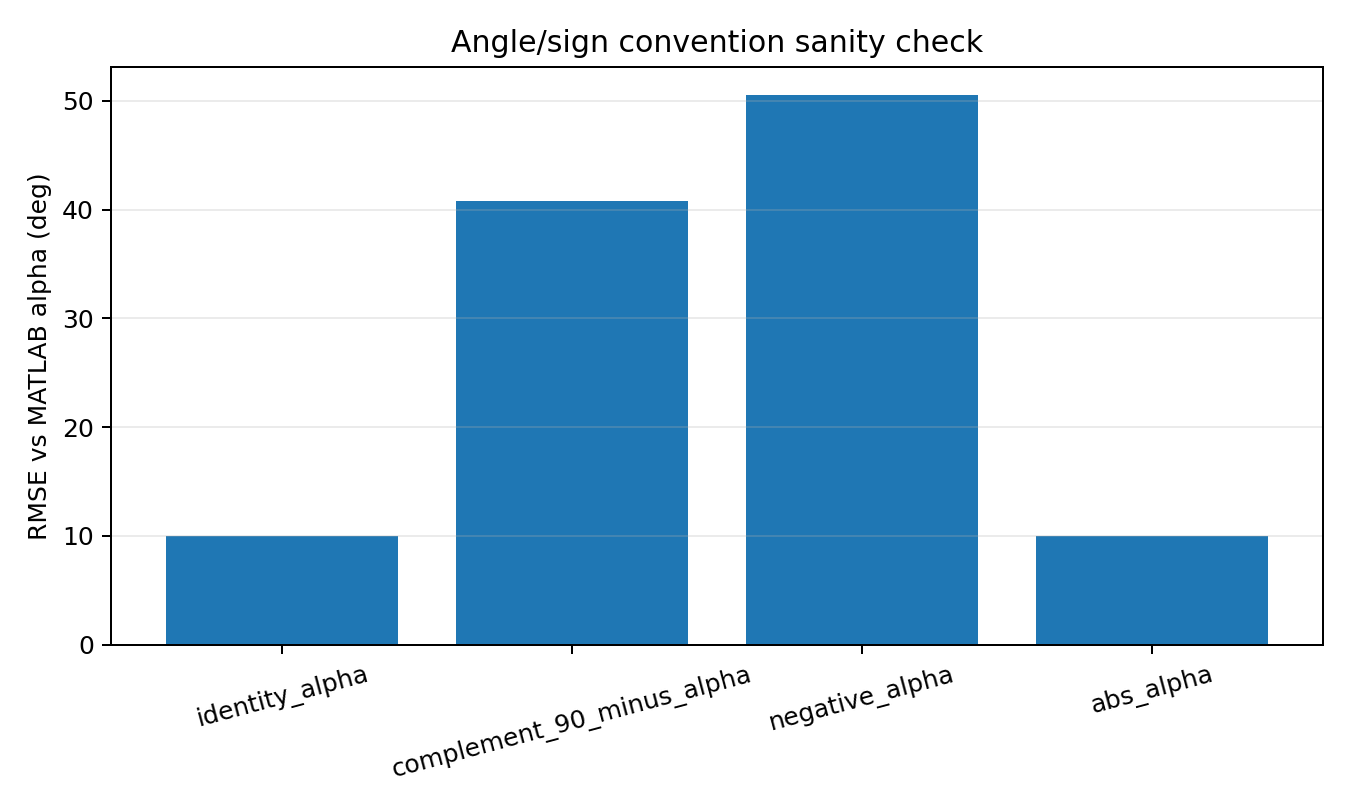

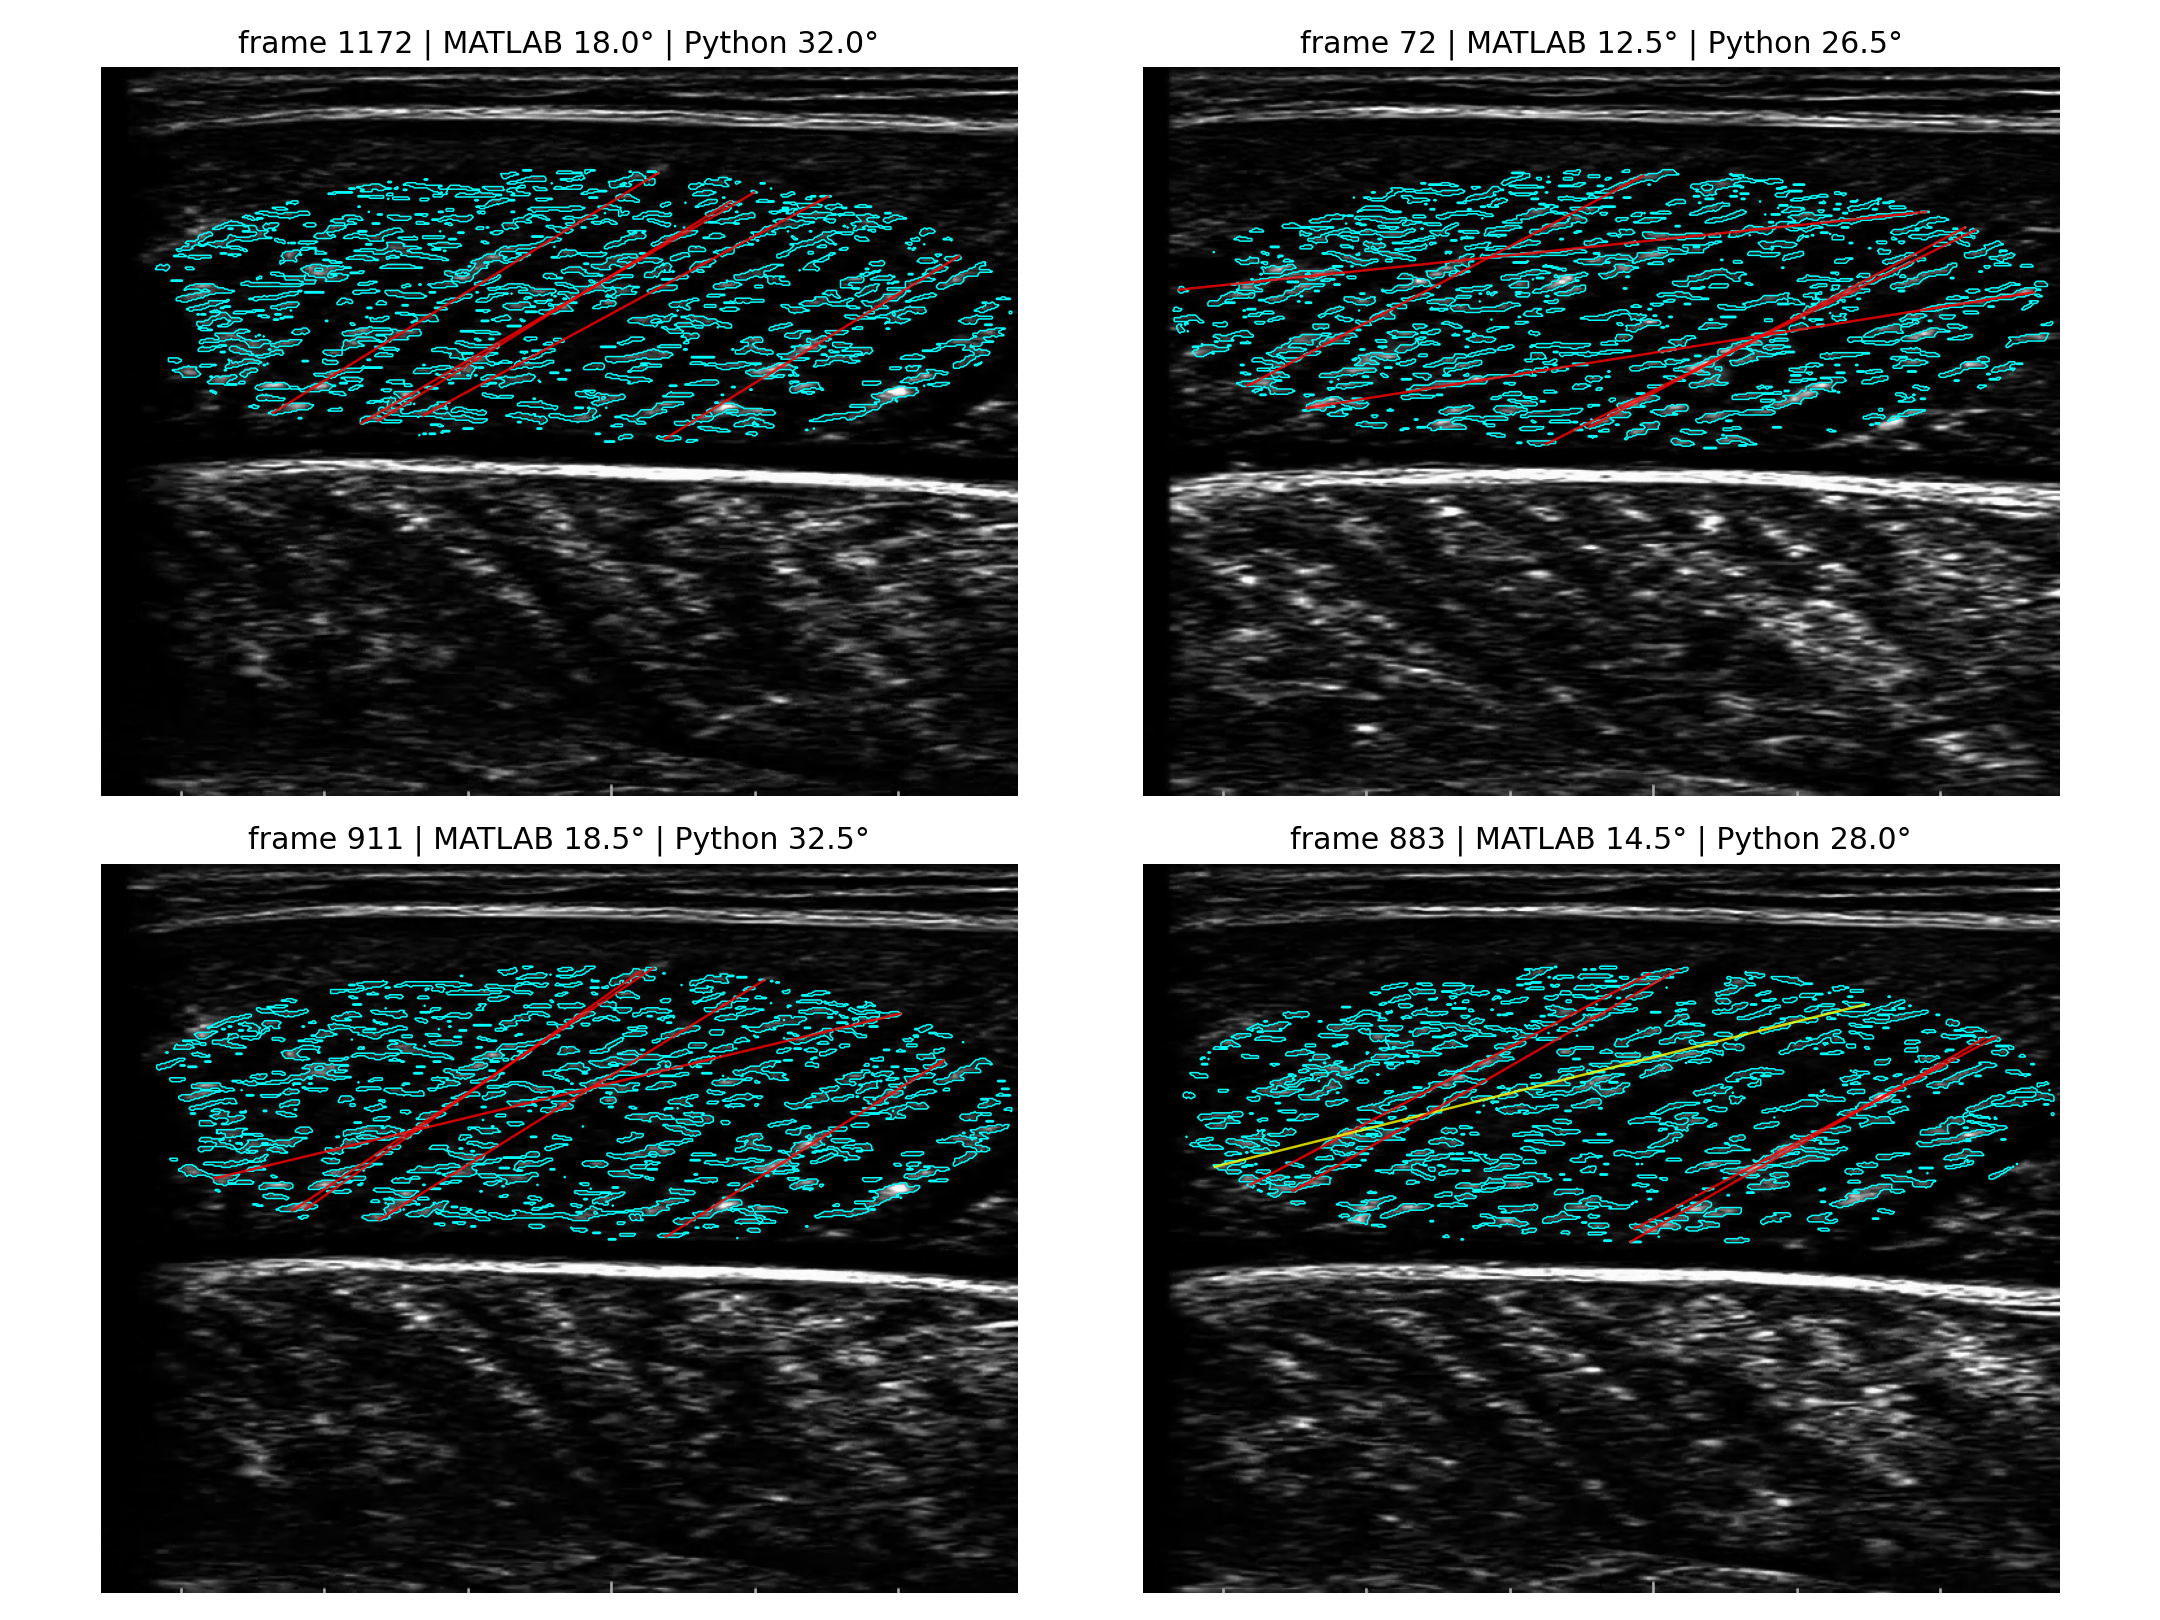

In [4]:
display(Image(filename=str(OUT / 'raw_timtrack_chain_summary.png')))
display(Image(filename=str(OUT / 'angle_convention_check.png')))
display(Image(filename=str(OUT / 'raw_timtrack_exemplar_overlays.png')))